In [1]:
import pytesseract
from PIL import Image
import cv2
import numpy as np

import re
import pandas as pd

pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

In [25]:
def preprocess_img_gray(image_path):
    """Preprocess DOSBox screenshot for better OCR"""
    
    img = cv2.imread(image_path)
    #Read image
    
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    #Convert to grayscale

    _, thresh = cv2.threshold(img_gray, 100, 255, cv2.THRESH_BINARY)

    denoised = cv2.fastNlMeansDenoising(thresh)
    #Denoise

    return img, img_gray, denoised


def extract_salary_auction_info(salary_auction_frame):
    player = salary_auction_frame[2].split(' ')[1]
    player_pos = salary_auction_frame[3].split(' ')[1]
    player_str = salary_auction_frame[5].split(' ')[1]
    player_team = salary_auction_frame[7].split(' ')[2]
    player_price = salary_auction_frame[9].split(' ')[2]
    player_minimum_wage = salary_auction_frame[11].split(' ')[2]
    
    return {
        'name': player,
        'position': player_pos,
        'strength': player_str,
        'team': player_team,
        'price': player_price,
        'minimum_wage': player_minimum_wage
    }

def img_processing(img):
    img = cv2.resize(img, None, fx=3, fy=3, interpolation=cv2.INTER_NEAREST)
    if np.mean(img) < 127:
        img = cv2.bitwise_not(img)
    return img


def prepare_dos_for_ocr(gray):
    # 1. Load image
    #img = cv2.imread(image_path)
    
    # 2. Convert to Grayscale
    #gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 3. Upscale (Crucial for low-res DOS fonts)
    img_resized = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_NEAREST)
    
    # 4. Threshold & Invert (Assuming light text on dark background)
    # This creates Black text on a White background
    _, processed_img = cv2.threshold(img_resized, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    return processed_img


def extract_squad_info(image_path, config = '--psm 6'):
    
    img, img_gray, img_denoised = preprocess_img_gray(image_path)
    img_denoised = img_gray

    img_denoised = img_processing(img)
    img_nrs = prepare_dos_for_ocr(img_gray)

    player_text = pytesseract.image_to_string(Image.fromarray(img_denoised[0:300,0:150]), config=config)

    all_pos = []
    all_names = []
    pos = 'G'
    for row in player_text.split('\n'):
        if row.strip() == '':
            continue
        row_components = row.split(' ')
        if row_components[0] == 'G':
            pos = row_components.pop(0)
        if row_components[0] == 'D':
            pos = row_components.pop(0)
        elif row_components[0] == 'M':
            pos = row_components.pop(0)
        elif row_components[0] == 'A' or row_components[0] == '@':
            pos = row_components.pop(0)
        all_pos += [pos]
        all_names += [' '.join(row_components)]

    processed_img_sth =  prepare_dos_for_ocr(img_gray[0:300,200:230])
    sth_values = process_nrs(processed_img_sth)

    processed_img_slr =  prepare_dos_for_ocr(img_gray[0:300,230:265])
    slr_values = process_nrs(processed_img_slr)

    processed_img_goals =  prepare_dos_for_ocr(img_gray[0:300,310:335])
    goals_values = process_nrs(processed_img_goals)

    squad_df = pd.DataFrame({'Position': all_pos, 'Name': all_names, 'Strength': sth_values, 'Salary': slr_values, 'Goals': goals_values})
    return squad_df


def process_nrs(img_section, config='--psm 6 --oem 3 -c tessedit_char_whitelist=0123456789'):
    nrs_text = pytesseract.image_to_string(Image.fromarray(img_section), config=config)
    nrs_values = [int(nrs_v) for nrs_v in nrs_text.split('\n') if re.match(r'\d+', nrs_v)]
    return nrs_values

def extract_squad_nrs(image_path):
    img, img_gray, img_denoised = preprocess_img_gray(image_path)

    processed_img_sth =  prepare_dos_for_ocr(img_gray[0:300,200:230])
    sth_values = process_nrs(processed_img_sth)

    processed_img_slr =  prepare_dos_for_ocr(img_gray[0:300,230:265])
    slr_values = process_nrs(processed_img_slr)

    processed_img_goals =  prepare_dos_for_ocr(img_gray[0:300,310:335])
    goals_values = process_nrs(processed_img_goals)

    squad_df = pd.DataFrame({'Strength': sth_values, 'Salary': slr_values, 'Goals': goals_values})
    return squad_df

In [26]:
image_path = specific_squad_frame

img, img_gray, img_denoised = preprocess_img_gray(specific_squad_frame)

processed_img_sth =  prepare_dos_for_ocr(img_gray[0:300,200:230])
sth_values = process_nrs(processed_img_sth)

processed_img_slr =  prepare_dos_for_ocr(img_gray[0:300,230:265])
slr_values = process_nrs(processed_img_slr)

processed_img_goals =  prepare_dos_for_ocr(img_gray[0:300,310:335])
goals_values = process_nrs(processed_img_goals)

squad_df = pd.DataFrame({'Strength': sth_values, 'Salary': slr_values, 'Goals': goals_values})

In [27]:
extract_squad_nrs(specific_squad_frame)

,Strength,Salary,Goals
0,11,900,0
1,12,1306,0
2,15,160,0
3,12,1206,0
4,15,1106,0
5,15,1106,0
6,15,1306,0
7,10,140,0
8,10,1106,0
9,11,1206,0


In [33]:
counter

36

In [32]:
import os

squad_frames = 'Data\Frames_Categories\Squad'

counter = 0
for squad_frame in os.listdir(squad_frames):
    try:
        specific_squad_frame = os.path.join(squad_frames, squad_frame)
        #print(extract_squad_info(specific_squad_frame))
        print(extract_squad_nrs(specific_squad_frame))
        print('------------------------------------------------')
        counter += 1
    except Exception as e:
        print(f"Error processing {squad_frame}: {e}")


    Strength  Salary  Goals
0         11     900      0
1         12    1306      0
2         15     160      0
3         12    1206      0
4         15    1106      0
5         15    1106      0
6         15    1306      0
7         10     140      0
8         10    1106      0
9         11    1206      0
10        11    1106      1
11        12    1206      0
12        10     100      0
13         6      70      0
14         8    1306      0
------------------------------------------------
    Strength  Salary  Goals
0         11     900      0
1         12    1306      0
2         15     160      0
3         12    1206      0
4         15    1106      0
5         15    1106      0
6         15    1306      0
7         10     140      0
8         10    1106      0
9         11    1206      0
10        11    1106      1
11        12    1206      0
12        10     100      0
13         6      70      0
14         8    1306      0
------------------------------------------------
    St

In [ ]:
image_path = specific_squad_frame
config = '--psm 6'

img, img_gray, img_denoised = preprocess_img_gray(image_path)
img_denoised = img_gray

player_text = pytesseract.image_to_string(Image.fromarray(img_denoised[0:300,0:150]), config=config)

all_pos = []
all_names = []
for row in player_text.split('\n'):
    if row.strip() == '':
        continue
    row_components = row.split(' ')
    if row_components[0] == 'G':
        pos = row_components.pop(0)
    if row_components[0] == 'D':
        pos = row_components.pop(0)
    elif row_components[0] == 'M':
        pos = row_components.pop(0)
    elif row_components[0] == 'A' or row_components[0] == '@':
        pos = row_components.pop(0)
    all_pos += [pos]
    all_names += [' '.join(row_components)]

strength_text = pytesseract.image_to_string(Image.fromarray(img_denoised[0:300,200:230]), config=config)
strength_values = [int(sth_v) for sth_v in strength_text.split('\n') if re.match(r'\d+', sth_v)]

salary_text = pytesseract.image_to_string(Image.fromarray(img_denoised[0:300,230:265]), config=config)
salary_values = [int(sal_v) for sal_v in salary_text.split('\n') if re.match(r'\d+', sal_v)]
#Will it capure large salaries (extra digits)?

goal_text = pytesseract.image_to_string(Image.fromarray(img_denoised[0:300,310:335]), config=config)
goal_values = [int(gol_v) for gol_v in goal_text.split('\n') if re.match(r'\d+', gol_v)]
#TO DO - Capture "*"/"." for contract length

squad_df = pd.DataFrame({'Position': all_pos, 'Name': all_names, 'Strength': strength_values, 'Salary': salary_values, 'Goals': goal_values})

ValueError: All arrays must be of the same length

In [ ]:
pd.DataFrame({'Position': all_pos, 'Name': all_names, 'Strength': strength_values})

ValueError: All arrays must be of the same length

In [ ]:
strength_values

[1, 15, 15, 15, 10, 10, 10, 6, 8]

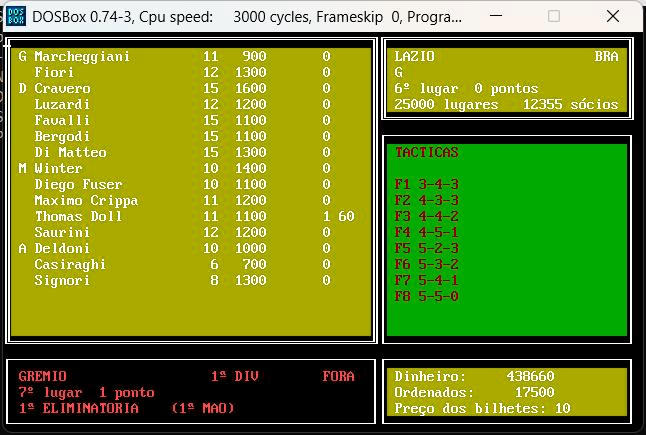

In [ ]:
from PIL import Image

img = cv2.imread(specific_squad_frame)
#Image.fromarray(img[30:,])
Image.fromarray(img)

In [ ]:
text_mask = cv2.adaptiveThreshold(
    img_gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=15,  
    C=2
)

In [ ]:
config = '--psm 7 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz'

In [ ]:
print(pytesseract.image_to_string(text_mask, config=config))

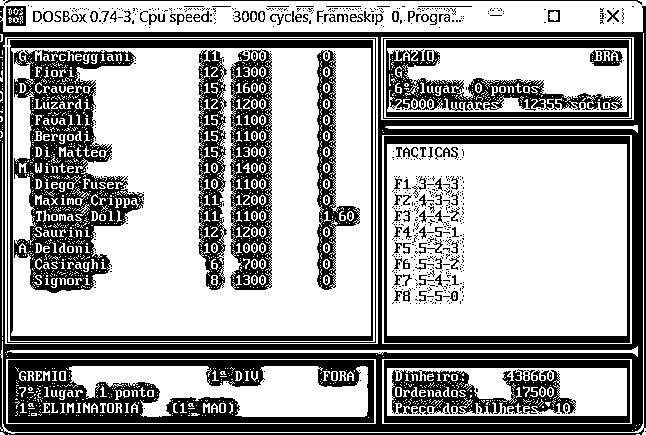

In [ ]:
Image.fromarray(text_mask)

In [ ]:
Image.fromarray(specific_squad_frame)

AttributeError: 'str' object has no attribute '__array_interface__'

In [ ]:
strength_text = pytesseract.image_to_string(Image.fromarray(img[0:300,200:230]), config=config)
strength_values = [int(sth_v) for sth_v in strength_text.split('\n') if re.match(r'\d+', sth_v)]

In [ ]:
Image.fromarray(img[0:300,200:230]).show()
strength_text = pytesseract.image_to_string(Image.fromarray(img[0:300,200:230]), config=config)
strength_values = [int(sth_v) for sth_v in strength_text.split('\n') if re.match(r'\d+', sth_v)]

In [ ]:
strength_text

'it\n2\n6\n2\n5\n6\n5\n10\n10\n11\n11\n2\n10\n\n6\n\n8\n'

In [ ]:
Image.fromarray(img[0:300,200:230])

In [ ]:
img_gray = cv2.cvtColor(img[0:300,200:230], cv2.COLOR_BGR2GRAY)
#Convert to grayscale

_, thresh = cv2.threshold(img_gray, 255, 255, cv2.THRESH_BINARY)

denoised = cv2.fastNlMeansDenoising(thresh)

Image.fromarray(img_gray).show()
Image.fromarray(denoised).show()

In [ ]:
kernel = np.array([[-1,-1,-1], 
                   [-1, 20,-1], 
                   [-1,-1,-1]])

img1 = Image.fromarray(cv2.filter2D(img[0:300,200:230], -1, kernel))

In [ ]:
custom_config = r'--oem 3 --psm 6 -c tessedit_char_whitelist=0123456789'

strength_text = pytesseract.image_to_string(img1, config=custom_config)

NameError: name 'img1' is not defined

In [ ]:
print(strength_text)

In [ ]:
strength_text = pytesseract.image_to_string(img_gray, config=config)
strength_values = [int(sth_v) for sth_v in strength_text.split('\n') if re.match(r'\d+', sth_v)]
strength_values

ValueError: invalid literal for int() with base 10: '5:'

In [ ]:
strength_text = pytesseract.image_to_string(denoised, config=config)
strength_values = [int(sth_v) for sth_v in strength_text.split('\n') if re.match(r'\d+', sth_v)]
strength_values

[]

In [ ]:
def preprocess_img_gray(image_path):
    """Attempts multiple image preprocessing techniques to enhance OCR accuracy"""
    
    img = cv2.imread(image_path)
    #Read image
    
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    #Convert to grayscale

    _, thresh = cv2.threshold(img_gray, 100, 255, cv2.THRESH_BINARY)
    denoised = cv2.fastNlMeansDenoising(thresh)
    #Denoise

    text_mask = cv2.adaptiveThreshold(
    img_gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=15,  
    C=2
)

    return img, img_gray, denoised, text_mask

In [ ]:
config = '--psm 6'#'--psm 6 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz'

def get_player_and_position(image_path, config = '--psm 6'):
    counter = 0
    img, img_gray, img_denoised, text_mask = preprocess_img_gray(image_path)
    
    conversion_dics = {}

    for img_frame in [img, img_gray, img_denoised, text_mask]:
        player_text = pytesseract.image_to_string(Image.fromarray(img_frame[0:300,0:150]), config=config)
        all_pos = []
        all_names = []
        for row in player_text.split('\n'):
            if row.strip() == '':
                continue
            row_components = row.split(' ')
            if row_components[0] == 'G':
                pos = row_components.pop(0)
            if row_components[0] == 'D':
                pos = row_components.pop(0)
            elif row_components[0] == 'M':
                pos = row_components.pop(0)
            elif row_components[0] == 'A' or row_components[0] == '@':
                pos = row_components.pop(0)
            all_pos += [pos]
            all_names += [' '.join(row_components)]

            conversion_dics[counter] =  [all_pos, all_names]
            counter += 1


    return conversion_dics

In [ ]:
get_player_and_position(squad_frame)

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [ ]:
image_path = specific_squad_frame

config = '--psm 6'
config = '--psm 6 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz \-'


counter = 0
img, img_gray, img_denoised, text_mask = preprocess_img_gray(image_path)

conversion_dics = {}

for img_frame in [img, img_gray, img_denoised, text_mask]:
    player_text = pytesseract.image_to_string(Image.fromarray(img_frame[0:300,0:150]), config=config)
    all_pos = []
    all_names = []
    for row in player_text.split('\n'):
        if row.strip() == '':
            continue
        row_components = row.split(' ')
        if row_components[0] == 'G':
            pos = row_components.pop(0)
        if row_components[0] == 'D':
            pos = row_components.pop(0)
        elif row_components[0] == 'M':
            pos = row_components.pop(0)
        elif row_components[0] == 'A' or row_components[0] == '@':
            pos = row_components.pop(0)
        all_pos += [pos]
        all_names += [' '.join(row_components)]

    conversion_dics[counter] =  [all_pos, all_names]
    counter += 1


In [ ]:
img = cv2.imread(specific_squad_frame)
#Read image

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#Convert to grayscale

_, thresh = cv2.threshold(img_gray, 100, 255, cv2.THRESH_BINARY)
denoised = cv2.fastNlMeansDenoising(thresh)
#Denoise

text_mask = cv2.adaptiveThreshold(
img_gray, 255,
cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
cv2.THRESH_BINARY,
blockSize=15,  
C=2
)

In [ ]:
text_mask

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], shape=(435, 646), dtype=uint8)

In [ ]:
for i in conversion_dics.keys():
    print('Positions:', len(conversion_dics[i][0]))
    print('Names:', len(conversion_dics[i][1]))

Positions: 15
Names: 15
Positions: 15
Names: 15
Positions: 2
Names: 2
Positions: 16
Names: 16


In [ ]:
conversion_dics[3]

[['A',
  'A',
  'A',
  'A',
  'A',
  'A',
  'A',
  'A',
  'A',
  'A',
  'A',
  'A',
  'A',
  'A',
  'A',
  'A',
  'A'],
 ['DOSBéx0:74-37C',
  '————',
  'arnarchegg ian',
  'Fiori',
  '| DaCeaverc,',
  'Litgardi',
  '| ME Favalli',
  '| ME Bergodi,',
  'ij matten,',
  'M-winterd',
  'Diegd, Fuser',
  'axing Ceippas',
  'Thoma DoLL',
  '‘SauFini',
  '‘A. Dé ldoni:',
  '‘Caivaghi',
  'Signor']]

In [ ]:
DOS_PALETTE = np.array([
    [0,0,0],       [0,0,170],     [0,170,0],     [0,170,170],
    [170,0,0],     [170,0,170],   [170,85,0],    [170,170,170],
    [85,85,85],    [85,85,255],   [85,255,85],   [85,255,255],
    [255,85,85],   [255,85,255],  [255,255,85],  [255,255,255]
], dtype=np.float32)

def quantise_to_palette(img_bgr):
    """Snap every pixel to its nearest DOS colour."""
    pixels = img_bgr.reshape(-1, 3).astype(np.float32)
    dists  = np.linalg.norm(pixels[:, None] - DOS_PALETTE[None, :], axis=2)
    labels = np.argmin(dists, axis=1)
    quantised = DOS_PALETTE[labels].reshape(img_bgr.shape).astype(np.uint8)
    return quantised, labels.reshape(img_bgr.shape[:2])


def binarise_region(labels, row_start, row_end):
    """
    For a given row band, find the majority colour (background)
    and minority colour (text), return a clean binary image.
    """
    region_labels = labels[row_start:row_end, :]
    counts = np.bincount(region_labels.ravel(), minlength=16)
    bg_label   = np.argmax(counts)
    counts[bg_label] = 0
    text_label = np.argmax(counts)

    binary = np.where(region_labels == text_label, 255, 0).astype(np.uint8)
    return binary

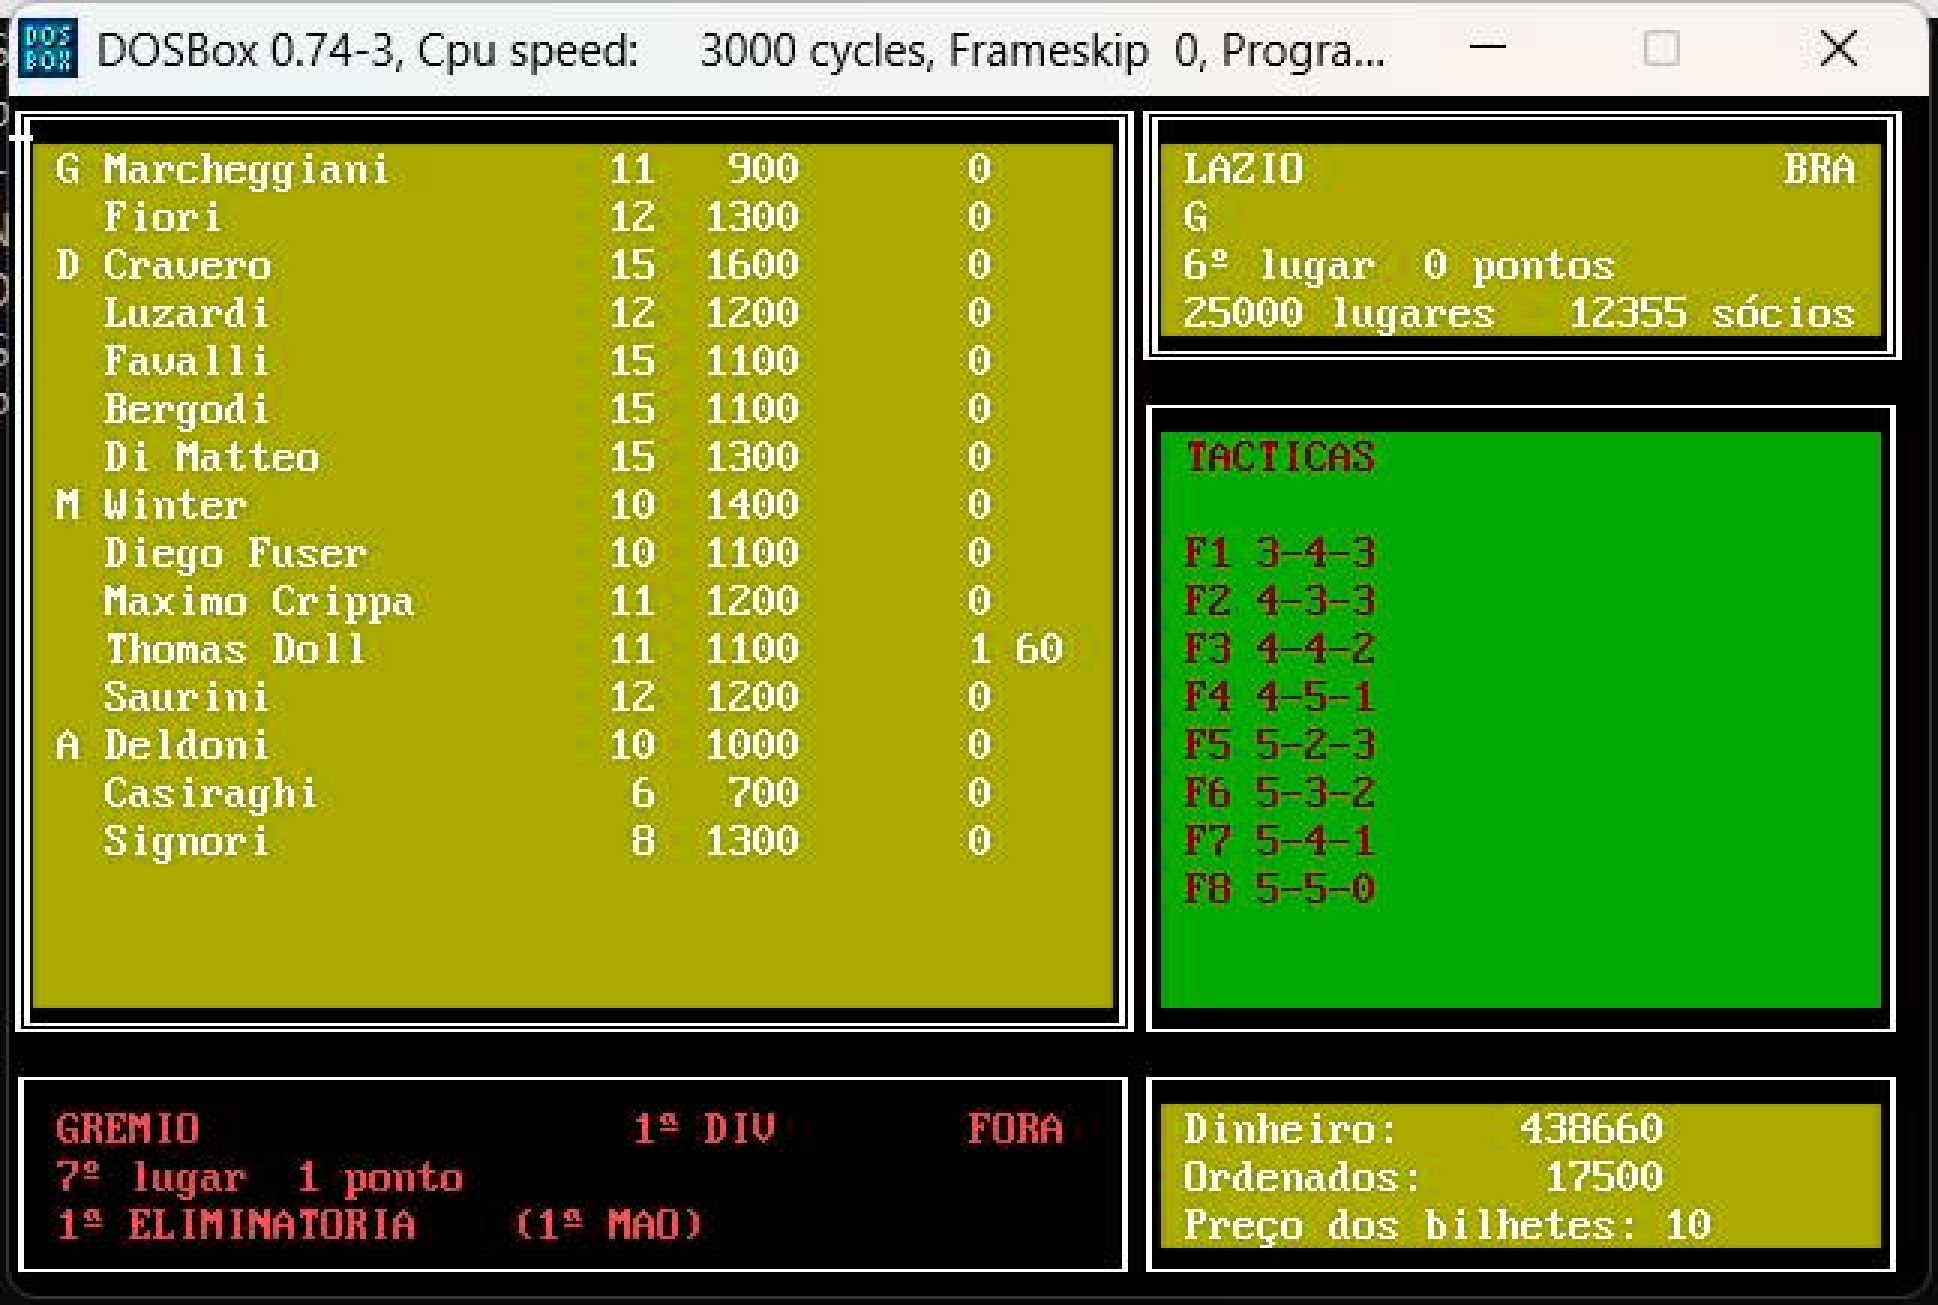

In [ ]:
Image.fromarray(img)

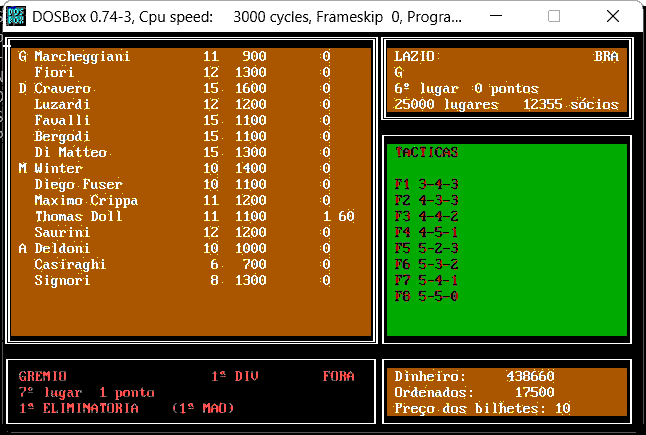

In [ ]:
Image.fromarray(quantise_to_palette(img)[0])

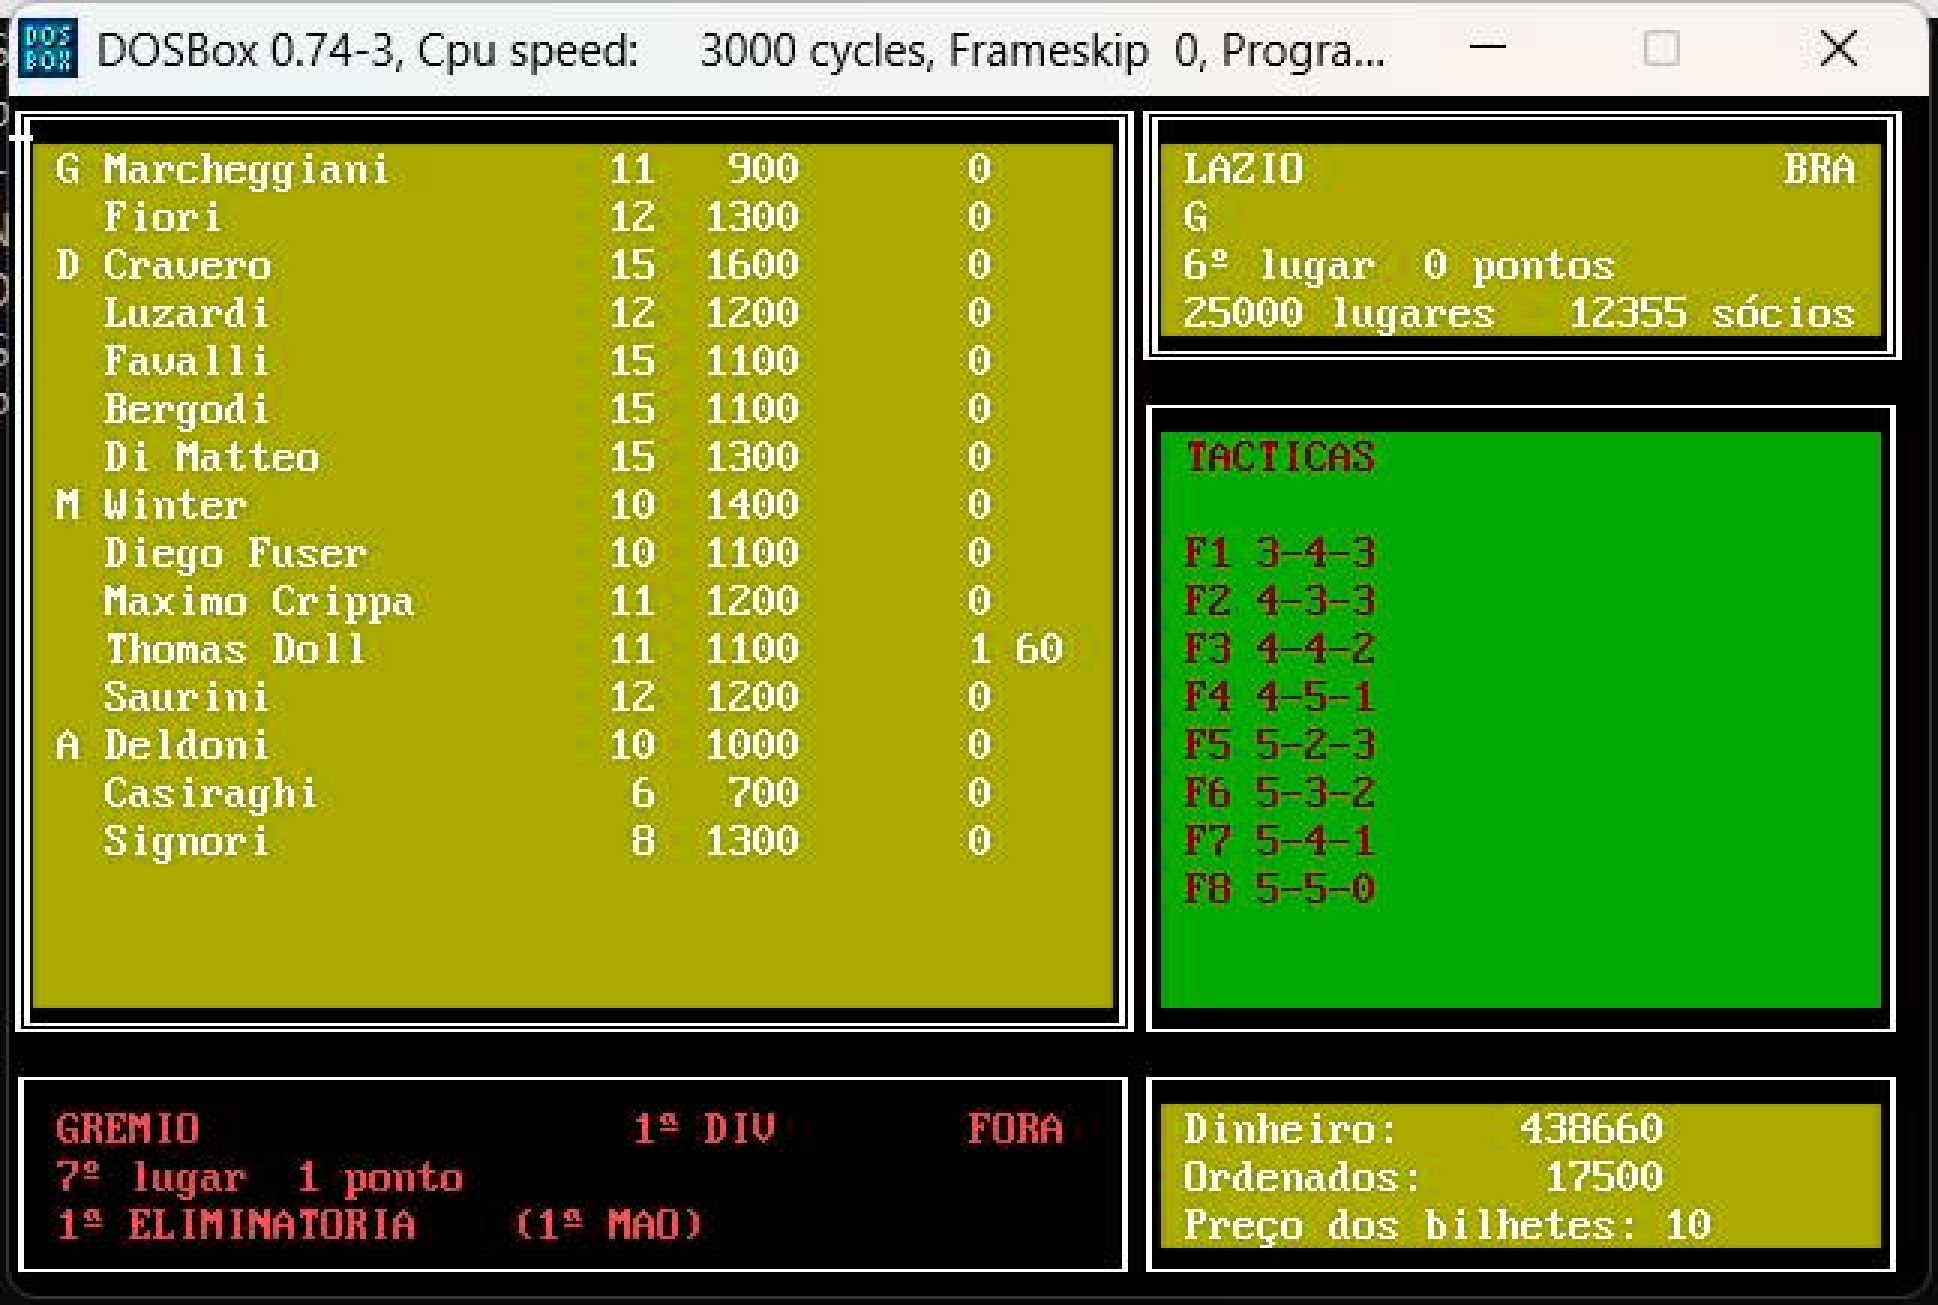

In [ ]:
img = cv2.imread(specific_squad_frame)
img1 = cv2.resize(img, None, fx=3, fy=3, interpolation=cv2.INTER_NEAREST)
Image.fromarray(img1)

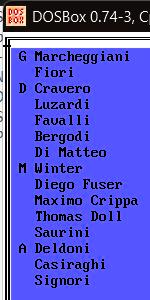

In [ ]:
img = cv2.imread(specific_squad_frame)

if np.mean(img[0:300,0:150]) < 127:
    img1 = cv2.bitwise_not(img[0:300,0:150])
Image.fromarray(img1)

In [ ]:
player_text = pytesseract.image_to_string(Image.fromarray(img[0:300,0:150]), config=config)
print(player_text)

fan
er
Pippa
DLL

i



In [ ]:
def img_processing(img):
    img = cv2.resize(img, None, fx=3, fy=3, interpolation=cv2.INTER_NEAREST)
    if np.mean(img) < 127:
        img = cv2.bitwise_not(img)
    return img

In [ ]:
def preprocess_img_gray(image_path):
    """Preprocess DOSBox screenshot for better OCR"""
    
    img = cv2.imread(image_path)
    #Read image
    
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    #Convert to grayscale

    _, thresh = cv2.threshold(img_gray, 100, 255, cv2.THRESH_BINARY)

    denoised = cv2.fastNlMeansDenoising(thresh)
    #Denoise

    return img, img_gray, denoised


def extract_salary_auction_info(salary_auction_frame):
    player = salary_auction_frame[2].split(' ')[1]
    player_pos = salary_auction_frame[3].split(' ')[1]
    player_str = salary_auction_frame[5].split(' ')[1]
    player_team = salary_auction_frame[7].split(' ')[2]
    player_price = salary_auction_frame[9].split(' ')[2]
    player_minimum_wage = salary_auction_frame[11].split(' ')[2]
    
    return {
        'name': player,
        'position': player_pos,
        'strength': player_str,
        'team': player_team,
        'price': player_price,
        'minimum_wage': player_minimum_wage
    }

def img_processing(img):
    #img = cv2.resize(img, None, fx=3, fy=3, interpolation=cv2.INTER_NEAREST)
    if np.mean(img) < 127:
        img = cv2.bitwise_not(img)
    return img

image_path = specific_squad_frame
config = '--psm 6'
    
img, img_gray, img_denoised = preprocess_img_gray(image_path)
img_denoised = img_gray

img_denoised = img_processing(img)

player_text = pytesseract.image_to_string(Image.fromarray(img_denoised[0:300,0:150]), config=config)

all_pos = []
all_names = []
pos = 'G'
for row in player_text.split('\n'):
    if row.strip() == '':
        continue
    row_components = row.split(' ')
    if row_components[0] == 'G':
        pos = row_components.pop(0)
    if row_components[0] == 'D':
        pos = row_components.pop(0)
    elif row_components[0] == 'M':
        pos = row_components.pop(0)
    elif row_components[0] == 'A' or row_components[0] == '@':
        pos = row_components.pop(0)
    all_pos += [pos]
    all_names += [' '.join(row_components)]

strength_text = pytesseract.image_to_string(Image.fromarray(img_denoised[0:300,200:230]), config=config)
strength_values = [int(sth_v) for sth_v in strength_text.split('\n') if re.match(r'\d+', sth_v)]

salary_text = pytesseract.image_to_string(Image.fromarray(img_denoised[0:300,230:265]), config=config)
salary_values = [int(sal_v) for sal_v in salary_text.split('\n') if re.match(r'\d+', sal_v)]
#Will it capure large salaries (extra digits)?

goal_text = pytesseract.image_to_string(Image.fromarray(img_denoised[0:300,310:335]), config=config)
goal_values = [int(gol_v) for gol_v in goal_text.split('\n') if re.match(r'\d+', gol_v)]
#TO DO - Capture "*"/"." for contract length

squad_df = pd.DataFrame({'Position': all_pos, 'Name': all_names, 'Strength': strength_values, 'Salary': salary_values, 'Goals': goal_values})


ValueError: All arrays must be of the same length

In [ ]:
strength_values

[12, 5, 12, 5, 5, 5, 19, 10, 11, 11, 12, 10, 6, 8]

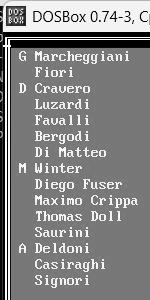

In [ ]:
Image.fromarray(img_denoised[0:300,0:150])

In [ ]:
Image.fromarray(img_denoised[0:300,200:230])

In [ ]:
pytesseract.image_to_string(Image.fromarray(img_denoised[0:300,200:230]), config=config)

'it\n12\n5\n12\n5\n5\n5\n19\n10\n11\n11\n12\n10\n\n6\n\n8\n'

In [ ]:
config = '--psm 6 --oem 3 -c tessedit_char_whitelist=0123456789'
print(pytesseract.image_to_string(Image.fromarray(img[0:300,200:230]), config=config))

1
2
6
2
5
6
5
10
10
11
11
2
10

6

8



In [ ]:
import easyocr
reader = easyocr.Reader(['en'])
results = reader.readtext(img, detail=0)

ModuleNotFoundError: No module named 'easyocr'

In [ ]:
import easyocr
reader = easyocr.Reader(['pt']) # this needs to run only once to load the model into memory
result = reader.readtext(specific_squad_frame[0:300,200:230])

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


TypeError: string indices must be integers, not 'tuple'

In [ ]:
result = reader.readtext(specific_squad_frame)

c:\Users\guilh\Git\Elifoot\.venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
result

[([[np.int32(4), np.int32(4)],
   [np.int32(218), np.int32(4)],
   [np.int32(218), np.int32(29)],
   [np.int32(4), np.int32(29)]],
  'E DOSBox 0.74-3, Cpu speed:',
  np.float64(0.7344251231258992)),
 ([[np.int32(231), np.int32(7)],
   [np.int32(453), np.int32(7)],
   [np.int32(453), np.int32(28)],
   [np.int32(231), np.int32(28)]],
  '3000 cycles; Frameskip 0, Progra',
  np.float64(0.5947807046889753)),
 ([[np.int32(17), np.int32(49)],
   [np.int32(133), np.int32(49)],
   [np.int32(133), np.int32(67)],
   [np.int32(17), np.int32(67)]],
  'G Marchegg iani',
  np.float64(0.8294834654771422)),
 ([[np.int32(241), np.int32(49)],
   [np.int32(269), np.int32(49)],
   [np.int32(269), np.int32(65)],
   [np.int32(241), np.int32(65)]],
  '900',
  np.float64(0.9939335058380482)),
 ([[np.int32(393), np.int32(49)],
   [np.int32(439), np.int32(49)],
   [np.int32(439), np.int32(65)],
   [np.int32(393), np.int32(65)]],
  'LAZIO',
  np.float64(0.7825351145656548)),
 ([[np.int32(593), np.int32(49)],
   [

In [ ]:
pd.DataFrame(result)

,0,1,2
0,"[[4, 4], [218, 4], [218, 29], [4, 29]]","E DOSBox 0.74-3, Cpu speed:",0.734425
1,"[[231, 7], [453, 7], [453, 28], [231, 28]]","3000 cycles; Frameskip 0, Progra",0.594781
2,"[[17, 49], [133, 49], [133, 67], [17, 67]]",G Marchegg iani,0.829483
3,"[[241, 49], [269, 49], [269, 65], [241, 65]]",900,0.993934
4,"[[393, 49], [439, 49], [439, 65], [393, 65]]",LAZIO,0.782535
5,"[[593, 49], [621, 49], [621, 65], [593, 65]]",BRA,0.995584
6,"[[33, 65], [77, 65], [77, 81], [33, 81]]",Fiori,0.999829
7,"[[233, 65], [269, 65], [269, 81], [233, 81]]",1300,0.999124
8,"[[33, 81], [93, 81], [93, 97], [33, 97]]",Crauero,0.912722
9,"[[233, 81], [269, 81], [269, 97], [233, 97]]",1600,0.996970
